In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [5]:
df.drop(["deck","embark_town","alive","class","who","adult_male"],axis=1,inplace=True)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,True
887,1,1,female,19.0,0,0,30.0000,S,True
888,0,3,female,NaN,1,2,23.4500,S,False
889,1,1,male,26.0,0,0,30.0000,C,True


In [6]:
df.isnull().sum()

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
alone         0
dtype: int64

In [7]:
df["age"].fillna(df["age"].mean(),inplace=True)
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    2
alone       0
dtype: int64

In [8]:
df.dropna(subset=["embarked"],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 63.4+ KB


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


In [10]:
df["alone"] = df["alone"].astype(int)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,0
1,1,1,0,38.0,1,0,71.2833,0,0
2,1,3,0,26.0,0,0,7.9250,2,1
3,1,1,0,35.0,1,0,53.1000,2,0
4,0,3,1,35.0,0,0,8.0500,2,1


In [11]:
X = df.drop("survived",axis=1)
y = df["survived"]

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)


0.8033707865168539

In [15]:
confusion_matrix(y_test,y_pred)

array([[90, 19],
       [16, 53]])

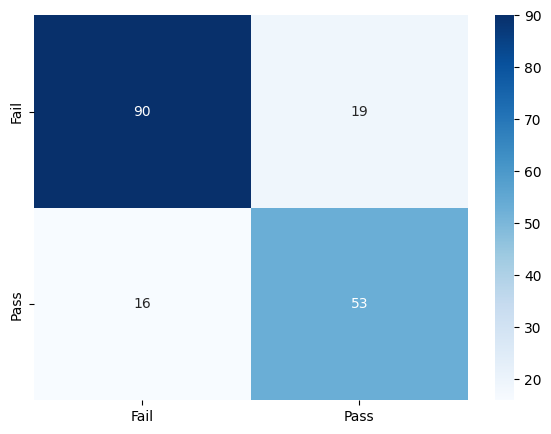

In [16]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.show()

In [17]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       109
           1       0.74      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.80      0.79       178
weighted avg       0.81      0.80      0.80       178



In [18]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.000000,1,0,7.2500,2,0
1,1,1,0,38.000000,1,0,71.2833,0,0
2,1,3,0,26.000000,0,0,7.9250,2,1
3,1,1,0,35.000000,1,0,53.1000,2,0
4,0,3,1,35.000000,0,0,8.0500,2,1
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,2,1
887,1,1,0,19.000000,0,0,30.0000,2,1
888,0,3,0,29.699118,1,2,23.4500,2,0
889,1,1,1,26.000000,0,0,30.0000,0,1


In [19]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_train_Scaler = X_train
X_test_Scaler = X_test
X_train_Scaler[["age","fare"]] = Scaler.fit_transform(X_train_Scaler[["age","fare"]])
X_test_Scaler[["age","fare"]] = Scaler.fit_transform(X_test_Scaler[["age","fare"]])
# X_test_Scaler
X_train_Scaler

,pclass,sex,age,sibsp,parch,fare,embarked,alone
708,1,0,-0.599636,0,0,2.430597,2,1
240,3,0,-0.012500,1,0,-0.358135,0,0
382,3,1,0.162966,0,0,-0.490949,2,1
792,3,0,-0.012500,8,2,0.762595,2,0
683,3,1,-1.209717,5,2,0.301860,2,0
...,...,...,...,...,...,...,...,...
107,3,1,-0.012500,0,0,-0.494000,2,1
271,3,1,-0.370855,0,0,-0.652155,2,1
862,1,0,1.383129,0,0,-0.124717,2,1
436,3,0,-0.675896,2,2,0.047083,2,0


In [20]:
from sklearn.neighbors import KNeighborsClassifier

KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train_Scaler,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
y_pred_knn = KNN_model.predict(X_test_Scaler)
accuracy_score(y_test,y_pred_knn)

0.8089887640449438

In [22]:
confusion_matrix(y_test,y_pred_knn)

array([[90, 19],
       [15, 54]])

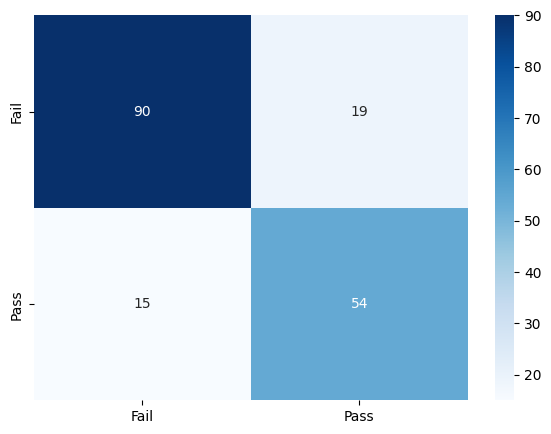

In [23]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test,y_pred_knn),annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.show()

In [24]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84       109
           1       0.74      0.78      0.76        69

    accuracy                           0.81       178
   macro avg       0.80      0.80      0.80       178
weighted avg       0.81      0.81      0.81       178



In [25]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_train_Scaler_knn = Scaler.fit_transform(X_train)
X_test_Scaler_knn = Scaler.fit_transform(X_test)
X_test_Scaler_knn
# X_train_Scaler_knn

array([[ 0.87837838,  0.83380939, -0.06636703, ..., -0.47215047,
         0.5836712 ,  0.82416338],
       [-1.52702703, -1.19931487, -1.20458188, ...,  1.69902381,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487, -1.20458188, ..., -0.40656752,
        -1.88998295, -1.21335165],
       ...,
       [ 0.87837838, -1.19931487,  0.74664358, ..., -0.01653915,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487,  0.34013828, ..., -0.31734953,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487, -2.01759249, ..., -0.30089329,
         0.5836712 , -1.21335165]], shape=(178, 8))

In [26]:
from sklearn.neighbors import KNeighborsClassifier

KNN_model_2 = KNeighborsClassifier(n_neighbors=5)
KNN_model_2.fit(X_train_Scaler_knn,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
y_pred_knn_2 = KNN_model_2.predict(X_test_Scaler_knn)
accuracy_score(y_test,y_pred_knn_2)

0.7921348314606742

In [28]:
confusion_matrix(y_test,y_pred_knn_2)

array([[89, 20],
       [17, 52]])

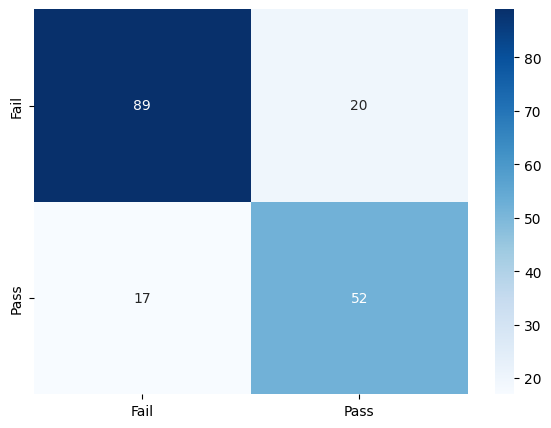

In [29]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test,y_pred_knn_2),annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.show()

In [30]:
print(classification_report(y_test,y_pred_knn_2))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       109
           1       0.72      0.75      0.74        69

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.79      0.79      0.79       178



In [31]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [32]:
y_pred_NB = model_NB.predict(X_test)
accuracy_score(y_test,y_pred_NB)

0.7696629213483146

In [33]:
confusion_matrix(y_test,y_pred_NB)

array([[84, 25],
       [16, 53]])

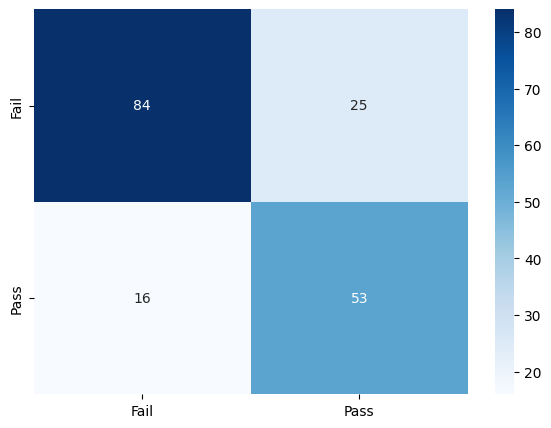

In [34]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test,y_pred_NB),annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.show()

In [35]:
print(classification_report(y_test,y_pred_NB))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80       109
           1       0.68      0.77      0.72        69

    accuracy                           0.77       178
   macro avg       0.76      0.77      0.76       178
weighted avg       0.78      0.77      0.77       178



In [36]:
model_NB_2 = GaussianNB()
model_NB_2.fit(X_train_Scaler,y_train)

,priors,None
,var_smoothing,1e-09


In [37]:
y_pred_NB_2 = model_NB_2.predict(X_test_Scaler)
accuracy_score(y_test,y_pred_NB_2)

0.7696629213483146

In [38]:
confusion_matrix(y_test,y_pred_NB_2)

array([[84, 25],
       [16, 53]])

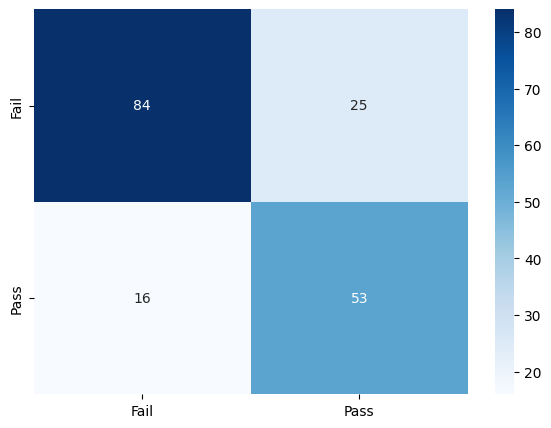

In [39]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test,y_pred_NB_2),annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.show()

In [40]:
print(classification_report(y_test,y_pred_NB_2))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80       109
           1       0.68      0.77      0.72        69

    accuracy                           0.77       178
   macro avg       0.76      0.77      0.76       178
weighted avg       0.78      0.77      0.77       178



In [41]:
from sklearn.tree import DecisionTreeClassifier

tre_model = DecisionTreeClassifier(random_state=42)
tre_model.fit(X_train_Scaler,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred_tree = tre_model.predict(X_test)
accuracy_score(y_test,y_pred_tree)

0.7528089887640449

In [43]:
confusion_matrix(y_test,y_pred_tree)

array([[87, 22],
       [22, 47]])

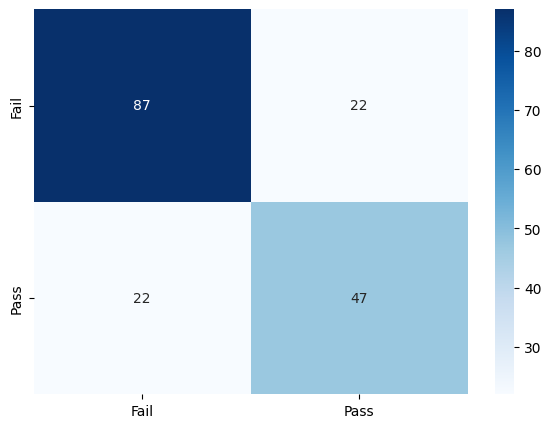

In [44]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test,y_pred_tree),annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.show()

In [45]:
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       109
           1       0.68      0.68      0.68        69

    accuracy                           0.75       178
   macro avg       0.74      0.74      0.74       178
weighted avg       0.75      0.75      0.75       178



In [46]:
from sklearn.svm import SVC
model_SVC = SVC(kernel="rbf")
model_SVC.fit(X_train_Scaler,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [57]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.000000,1,0,7.2500,2,0
1,1,1,0,38.000000,1,0,71.2833,0,0
2,1,3,0,26.000000,0,0,7.9250,2,1
3,1,1,0,35.000000,1,0,53.1000,2,0
4,0,3,1,35.000000,0,0,8.0500,2,1
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,2,1
887,1,1,0,19.000000,0,0,30.0000,2,1
888,0,3,0,29.699118,1,2,23.4500,2,0
889,1,1,1,26.000000,0,0,30.0000,0,1


In [56]:
X_train_Scaler

,pclass,sex,age,sibsp,parch,fare,embarked,alone
708,1,0,-0.599636,0,0,2.430597,2,1
240,3,0,-0.012500,1,0,-0.358135,0,0
382,3,1,0.162966,0,0,-0.490949,2,1
792,3,0,-0.012500,8,2,0.762595,2,0
683,3,1,-1.209717,5,2,0.301860,2,0
...,...,...,...,...,...,...,...,...
107,3,1,-0.012500,0,0,-0.494000,2,1
271,3,1,-0.370855,0,0,-0.652155,2,1
862,1,0,1.383129,0,0,-0.124717,2,1
436,3,0,-0.675896,2,2,0.047083,2,0


In [48]:
y_pred_svc = model_SVC.predict(X_test)
accuracy_score(y_test,y_pred_svc)

0.8202247191011236

In [49]:
confusion_matrix(y_test,y_pred_svc)

array([[92, 17],
       [15, 54]])

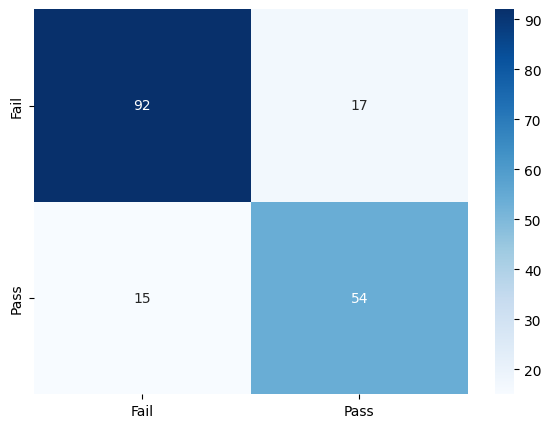

In [50]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test,y_pred_svc),annot=True,fmt="d",cmap="Blues",xticklabels=["Fail","Pass"],yticklabels=["Fail","Pass"])
plt.show()

In [51]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       109
           1       0.76      0.78      0.77        69

    accuracy                           0.82       178
   macro avg       0.81      0.81      0.81       178
weighted avg       0.82      0.82      0.82       178



In [52]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.000000,1,0,7.2500,2,0
1,1,1,0,38.000000,1,0,71.2833,0,0
2,1,3,0,26.000000,0,0,7.9250,2,1
3,1,1,0,35.000000,1,0,53.1000,2,0
4,0,3,1,35.000000,0,0,8.0500,2,1
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,2,1
887,1,1,0,19.000000,0,0,30.0000,2,1
888,0,3,0,29.699118,1,2,23.4500,2,0
889,1,1,1,26.000000,0,0,30.0000,0,1


In [53]:
X = df.drop("survived",axis=1)
y = df["survived"]

In [54]:
from sklearn.model_selection import cross_val_score
X_scaler = Scaler.fit_transform(X)

In [55]:
scores = cross_val_score(model_SVC,X_scaler,y,cv=5,scoring = "accuracy")
print(scores.mean())

0.8279375357074844
